In [13]:
import numpy as np
from keras import layers
from keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from keras.models import Model
from keras.preprocessing import image
from tensorflow.python.keras.utils import layer_utils
from keras.utils import get_file
from keras.applications.imagenet_utils import preprocess_input
import pydot
from IPython.display import SVG
from keras.utils import model_to_dot
from keras.utils import plot_model
from kt_utils import *

import keras.backend as k
k.set_image_data_format('channels_last')
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

%matplotlib inline

In [14]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

X_train = X_train_orig/255.
X_test = X_test_orig/255.

Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape = " + str(X_test.shape))
print ("Y_test shape = " + str(Y_test.shape))

number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape = (150, 64, 64, 3)
Y_test shape = (150, 1)


In [15]:
def model(input_shape):
    """
    input_shape: The height, width and channels as a tuple.
        Note that this does not include the 'batch' as a dimension.
        If ypu have a batch like 'X_train',
        then you can provide the input_shape using 
        X_train.shape[1:]
    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)
    X = Conv2D(32, (7, 7), strides=(1, 1), name='conv0')(X)
    X = BatchNormalization(axis=3, name='bn0')(X)
    X = Activation('relu')(X)

    X = MaxPooling2D((2, 2), name='max_pool')(X)
    X = Flatten()(X)
    X = Dense(1, activation='sigmoid', name='fc')(X)

    model = Model(inputs=X_input, outputs=X, name='HappyModel')

    return model

In [16]:
def HappyModel(input_shape):
    """
    Implementation of the HappyModel.

    Arguments:
    input_shape -- shape of the images of the dataset.
        (height, width, channels) as a tuple
        Note that this does not include the 'batch' as a dimension.
        If you have a batch like 'X_train',
        then you can provide the input_shape using X_train.shape[1:]

    Returns:
    model -- a Model() instance in Keras
    """

    X_input = Input(input_shape)

    X = ZeroPadding2D((3, 3))(X_input)
    X = Conv2D(32, (5, 5), strides=(1, 1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Dropout(0.3)(X)
    X = Activation("relu")(X)

    X = AveragePooling2D((2, 2))(X)
    X = Flatten()(X)
    X = Dense(1, activation="sigmoid")(X)

    model = Model(inputs=X_input, outputs=X, name="HappyModel")

    return model

In [17]:
happy_model = HappyModel(X_train.shape[1:])

In [18]:
happy_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [19]:
happy_model.fit(X_train, Y_train, batch_size=10, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.6583 - loss: 1.3601
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9350 - loss: 0.1721
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9533 - loss: 0.1149
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9367 - loss: 0.1529
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9100 - loss: 0.2489
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9400 - loss: 0.1616
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9767 - loss: 0.0869
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9683 - loss: 0.0846
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9567 - loss: 0.1132
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9683 - loss: 0.1007
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9717 - loss: 0.0891
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy:

In [20]:
predictions = happy_model.evaluate(X_test, Y_test, batch_size=5)

print("Loss = " + str(predictions[0]))
print("Test Accuracy = " + str(predictions[1]))

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9400 - loss: 0.1690
Loss = 0.16897286474704742
Test Accuracy = 0.9399999976158142


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
[[0.]]


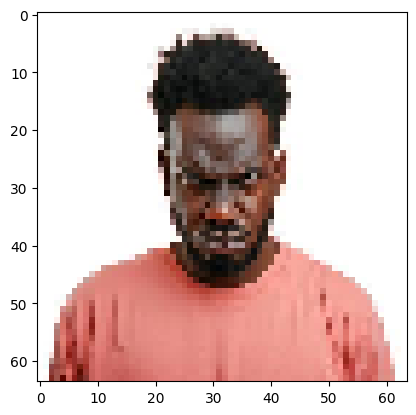

In [21]:
img_path = '/home/neville/Downloads/images.jpeg'

img = image.load_img(img_path, target_size=(64, 64))
imshow(img)

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

print(happy_model.predict(x))